In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 723.3 kB/s eta 0:01:07
   ---------------------------------------- 0.5/48.9 MB 723.3 kB/s eta 0:01:07
    --------------------------------------- 0.8/48.9 MB 885.8 kB/s eta 0:00:55
    --------------------------------------- 1.0/48.9 MB 850.9 kB/s eta 0:00:57
    --------------------------------------- 1.0/48.9 MB 850.9 kB/s eta 0:00:57
   - -------------------------------------- 1.3/48.9 MB 814.7 kB/s eta 0:00:59
   - -------------------------------------- 1.3/48.9 MB 814.7 kB/s eta 0:00:59
   - -------------------------------------- 1.6/48.9 MB 745.8 kB/s eta 0:01:04
   - -------------------------------------- 1.6/48.9 MB 745.8 kB/s eta 0:01:04
   - ----

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhbadole/bank-customer-churn-prediction-dataset")

print("Path to dataset files:", path)

100%|████████████████████████████████████████████████████████████████████████████████| 262k/262k [00:00<00:00, 329kB/s]

Extracting files...
Path to dataset files: C:\Users\BIT\.cache\kagglehub\datasets\saurabhbadole\bank-customer-churn-prediction-dataset\versions\2


In [4]:
import os

# 1. Automatically find the downloaded .csv file in the path
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file)

# 2. Load the dataset into pandas
df = pd.read_csv(full_csv_path)

# 3. Print basic portfolio stats
print(f"Loaded File: {csv_file}")
print(f"Dataset Shape: {df.shape}")
if 'Exited' in df.columns:
    print(f"Baseline Portfolio Churn Rate: {df['Exited'].mean() * 100:.2f}%")

df.head()

Loaded File: Churn_Modelling.csv
Dataset Shape: (10000, 14)
Baseline Portfolio Churn Rate: 20.37%


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Feature Engineering
df['Balance_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['Product_Tenure_Ratio'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['IsZeroBalance'] = (df['Balance'] == 0).astype(int)

# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# Prepare Features (X) and Target (y)
drop_cols = [col for col in ['RowNumber', 'CustomerId', 'Surname', 'Exited'] if col in df_encoded.columns]
X = df_encoded.drop(columns=drop_cols)
y = df_encoded['Exited']
print("Engineered features successfully. Model features:")
print(X.columns.tolist())

Engineered features successfully. Model features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Balance_Salary_Ratio', 'Product_Tenure_Ratio', 'IsZeroBalance', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


C:\Users\BIT\AppData\Local\Temp\ipykernel_7156\443798014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='NumOfProducts', y='Exited', ax=axes[0], palette='Blues_r')


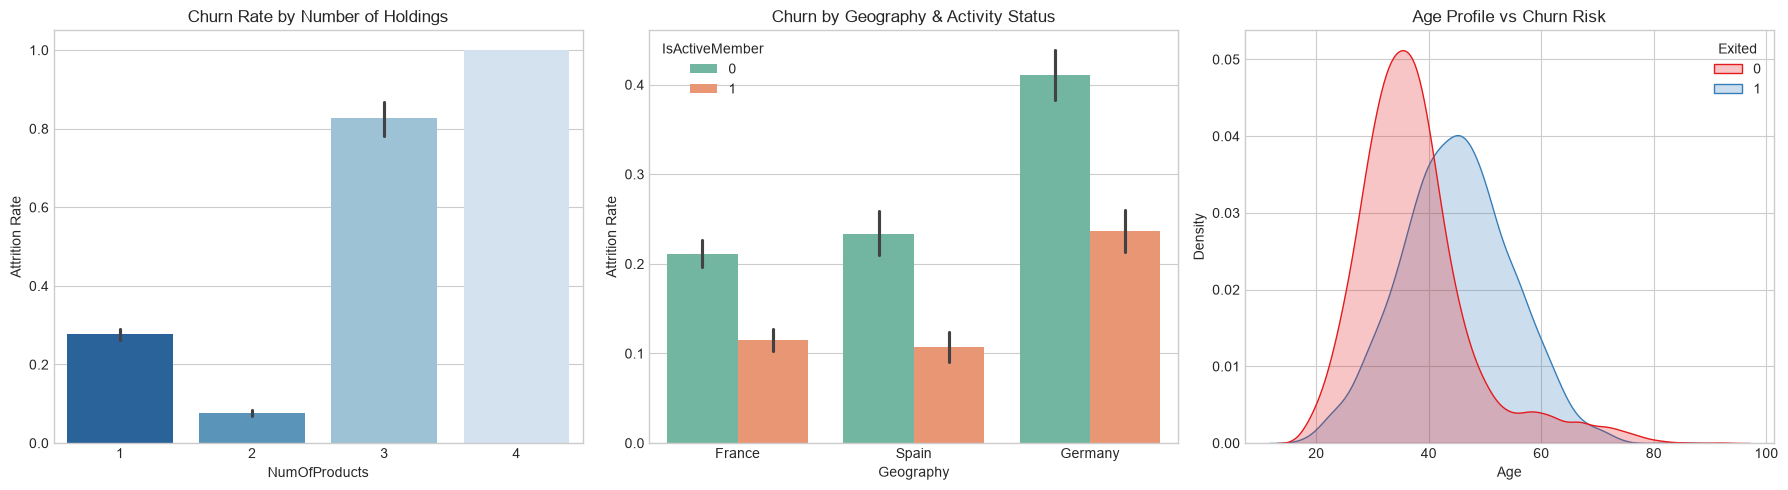

Total Portfolio Capital Currently Exited: $185,588,094.63


In [6]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn Rate by Number of Products
sns.barplot(data=df, x='NumOfProducts', y='Exited', ax=axes[0], palette='Blues_r')
axes[0].set_title('Churn Rate by Number of Holdings')
axes[0].set_ylabel('Attrition Rate')

# 2. Churn Rate by Geography & Activity Status
sns.barplot(data=df, x='Geography', y='Exited', hue='IsActiveMember', ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Geography & Activity Status')
axes[1].set_ylabel('Attrition Rate')

# 3. Age Profile Density by Attrition
sns.kdeplot(data=df, x='Age', hue='Exited', common_norm=False, fill=True, ax=axes[2], palette='Set1')
axes[2].set_title('Age Profile vs Churn Risk')

plt.tight_layout()
plt.show()

# Portfolio loss metric
portfolio_loss = df[df['Exited'] == 1]['Balance'].sum()
print(f"Total Portfolio Capital Currently Exited: ${portfolio_loss:,.2f}")

--- Classification Performance Report ---
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1593
           1       0.51      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000

ROC-AUC Score: 0.8693


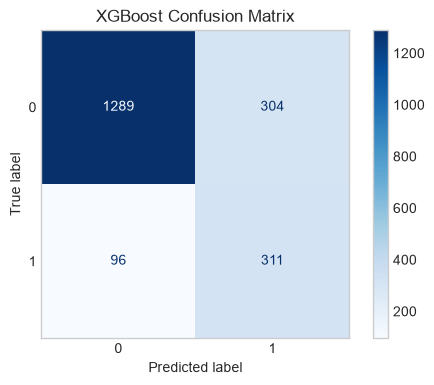

In [7]:
# Cell 5: Model Training & Evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Imbalance handling scale factor
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize & Train XGBoost
model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Model Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Output Results
print("--- Classification Performance Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.grid(False)
plt.show()

C:\Users\BIT\AppData\Local\Temp\ipykernel_7156\2035539694.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


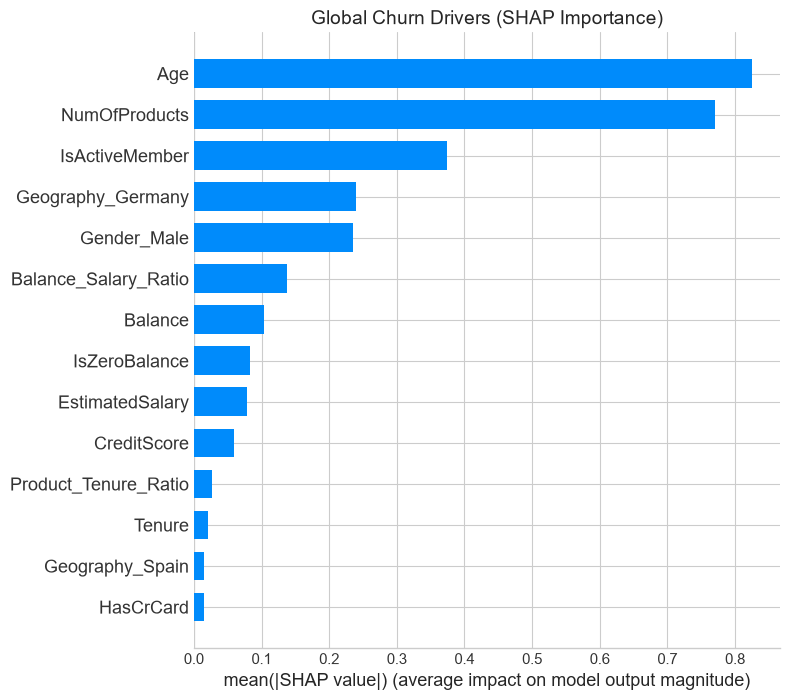

C:\Users\BIT\AppData\Local\Temp\ipykernel_7156\2035539694.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


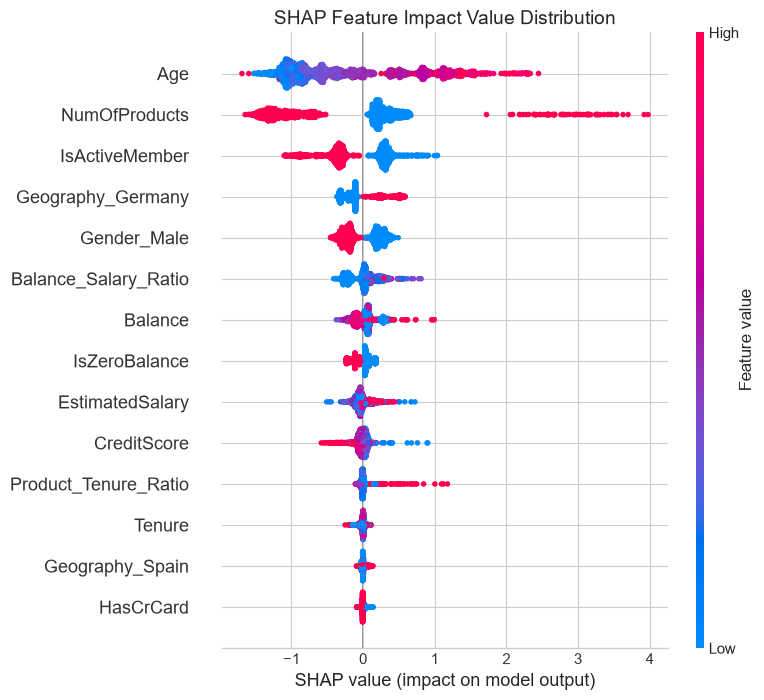

In [8]:

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# 1. Feature Importance Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Churn Drivers (SHAP Importance)", fontsize=14)
plt.tight_layout()
plt.show()

# 2. SHAP Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Impact Value Distribution", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Cell 7: Valuation & CSV Export
test_results = X_test.copy()
test_results['Actual_Exited'] = y_test
test_results['Predicted_Churn_Probability'] = y_proba
test_results['Expected_Balance_Risk'] = test_results['Balance'] * test_results['Predicted_Churn_Probability']

high_risk_threshold = 0.65
at_risk_segment = test_results[test_results['Predicted_Churn_Probability'] >= high_risk_threshold].sort_values(
    by='Expected_Balance_Risk', ascending=False
)

total_risk = test_results['Expected_Balance_Risk'].sum()
high_risk_capital = at_risk_segment['Balance'].sum()

print("--- Executive Risk Valuation Metrics ---")
print(f"Total Expected Portfolio Capital at Risk: ${total_risk:,.2f}")
print(f"Capital in High-Risk Segment (P >= {high_risk_threshold}): ${high_risk_capital:,.2f}")
print(f"High-Risk Customer Count: {len(at_risk_segment)} out of {len(X_test)} evaluated")

# Save outputs locally
test_results.to_csv('processed_churn_predictions.csv', index=False)
at_risk_segment.to_csv('high_risk_action_list.csv', index=False)
print("\nExported 'processed_churn_predictions.csv' and 'high_risk_action_list.csv' successfully!")

--- Executive Risk Valuation Metrics ---
Total Expected Portfolio Capital at Risk: $68,823,843.47
Capital in High-Risk Segment (P >= 0.65): $35,653,697.31
High-Risk Customer Count: 389 out of 2000 evaluated

Exported 'processed_churn_predictions.csv' and 'high_risk_action_list.csv' successfully!


In [10]:
import shutil

# Copy the CSV from the cache folder to your current project folder
shutil.copy(full_csv_path, 'Churn_Modelling.csv')
print("Successfully saved 'Churn_Modelling.csv' to your current working folder!")

Successfully saved 'Churn_Modelling.csv' to your current working folder!
